# Task 1: Problem Identification

## Selected Problem Type

**Image Classification**

---

# Explanation

The given dataset represents an image classification problem because each image belongs to one predefined category:

* Dent
* Normal
* Scratch
* Stain

The objective of the model is to analyze the entire image and assign one label to it based on the visible defect type.

---

# Why Image Classification is Appropriate

Image classification is suitable because:

1. Each image has a single class label

   * Every image represents one defect category only.

2. The task is to predict the overall category

   * The model only needs to determine whether the image contains:

     * a dent,
     * scratch,
     * stain,
     * or no defect (normal).

3. No localization is required

   * The dataset does not require:

     * bounding boxes,
     * object coordinates,
     * pixel-level masks,
     * or region annotations.

4. The focus is on visual pattern recognition

   * CNNs learn textures, shapes, edges, and defect patterns to classify the image correctly.

---

# Why Other Problem Types Are Not Suitable

## 1. Object Detection 

Object detection is used when the model must:

* locate objects using bounding boxes, and classify them.

This dataset does not contain object location annotations.

---

## 2. Semantic Segmentation 

Semantic segmentation assigns a class label to every pixel in the image.

The dataset does not provide pixel-wise masks for defects.

---

## 3. Instance Segmentation 

Instance segmentation identifies and separates multiple object instances individually.

The dataset only requires whole-image classification and not individual object separation.

---

# Final Conclusion

The dataset is best categorized as an **Image Classification** problem because the goal is to classify entire images into one of four defect categories:

* Dent
* Normal
* Scratch
* Stain

A CNN-based image classification model is therefore the most appropriate solution for this dataset.

# Task 2: Dataset Exploration

## Dataset Summary

* Total Classes: 4
* Classes:

  * Dent
  * Normal
  * Scratch
  * Stain

## Images per Class

| Class   | Number of Images | Sample Image Dimension |
| ------- | ---------------: | ---------------------- |
| Dent    |              120 | 96 × 96                |
| Normal  |              120 | 96 × 96                |
| Scratch |              120 | 96 × 96                |
| Stain   |              120 | 96 × 96                |

## Image Dimensions

* The dataset images are approximately **96 × 96 pixels**.
* For CNN training, images are usually resized to:

  * 128 × 128
  * or 224 × 224

## Dataset Balance

The dataset is **balanced** because all classes contain the same number of images (120 each).

This is beneficial because:

* the CNN model will not become biased toward one class,
* training becomes more stable,
* evaluation metrics become more reliable.






In [19]:
import os

os.makedirs("results", exist_ok=True)
os.makedirs("sample_predictions", exist_ok=True)

In [1]:
target_size = (128, 128)

In [2]:
rescale = 1./255

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# -----------------------------------------
# Dataset Path
# -----------------------------------------

dataset_path = r"E:\BITSOM\Assignment 5\Part 2\dataset"

# -----------------------------------------
# Image Parameters
# -----------------------------------------

IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

# -----------------------------------------
# Image Preprocessing + Augmentation
# -----------------------------------------

train_datagen = ImageDataGenerator(

    # Normalize pixel values
    rescale=1./255,

    # Data augmentation
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,

    # Split dataset
    validation_split=0.2
)

# -----------------------------------------
# Training Dataset
# -----------------------------------------

train_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(IMG_HEIGHT, IMG_WIDTH),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training'
)

# -----------------------------------------
# Validation/Test Dataset
# -----------------------------------------

validation_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(IMG_HEIGHT, IMG_WIDTH),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation'
)

# -----------------------------------------
# Display Class Labels
# -----------------------------------------

print(train_generator.class_indices)

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.
{'Dent': 0, 'Normal': 1, 'Scratch': 2, 'Stain': 3}


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# -----------------------------------------
# CNN Model
# -----------------------------------------

model = Sequential([

    # Input Layer
    Input(shape=(128,128,3)),

    # First Convolution Layer
    Conv2D(32, (3,3), activation='relu'),

    # First Pooling Layer
    MaxPooling2D(pool_size=(2,2)),

    # Second Convolution Layer
    Conv2D(64, (3,3), activation='relu'),

    # Second Pooling Layer
    MaxPooling2D(pool_size=(2,2)),

    # Third Convolution Layer
    Conv2D(128, (3,3), activation='relu'),

    # Third Pooling Layer
    MaxPooling2D(pool_size=(2,2)),

    # Flatten Layer
    Flatten(),

    # Dense Layer
    Dense(128, activation='relu'),

    # Dropout Layer
    Dropout(0.5),

    # Output Layer
    Dense(4, activation='softmax')
])

# -----------------------------------------
# Compile Model
# -----------------------------------------

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------------------
# Model Summary
# -----------------------------------------

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
##Task 5: Model Training and Evaluation

In [5]:
# -----------------------------------------
# Train CNN Model
# -----------------------------------------

history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.2578 - loss: 1.5227 - val_accuracy: 0.2500 - val_loss: 1.3889
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 848ms/step - accuracy: 0.2135 - loss: 1.3957 - val_accuracy: 0.2500 - val_loss: 1.3862
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 850ms/step - accuracy: 0.2396 - loss: 1.3901 - val_accuracy: 0.2500 - val_loss: 1.3852
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 846ms/step - accuracy: 0.3385 - loss: 1.3774 - val_accuracy: 0.2500 - val_loss: 1.3449
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 855ms/step - accuracy: 0.3359 - loss: 1.2949 - val_accuracy: 0.4792 - val_loss: 1.2956
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 849ms/step - accuracy: 0.3932 - loss: 1.2829 - val_accuracy: 0.4896 - val_loss: 1.0835
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 848ms/step - accuracy: 0.5000 - loss: 0.9869 - val_accuracy: 0.5312 - val_loss: 0.8687
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 867ms/step - accuracy: 0.5391 - loss: 0.9039 - val_accurac

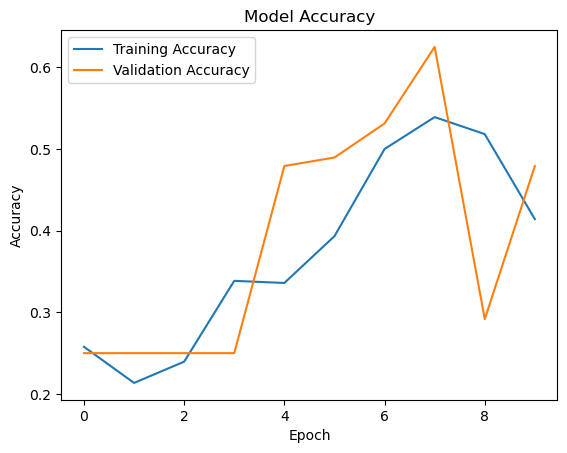

In [6]:
import matplotlib.pyplot as plt

# -----------------------------------------
# Accuracy Plot
# -----------------------------------------

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

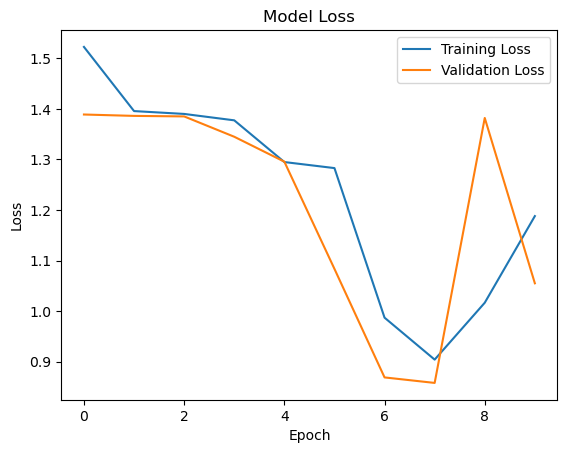

In [7]:
# -----------------------------------------
# Loss Plot
# -----------------------------------------

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

In [8]:
# -----------------------------------------
# Evaluate Model
# -----------------------------------------

loss, accuracy = model.evaluate(validation_generator)

print("Validation Loss:", loss)

print("Validation Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 454ms/step - accuracy: 0.4792 - loss: 1.0544
Validation Loss: 1.0544146299362183
Validation Accuracy: 0.4791666567325592


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 380ms/step


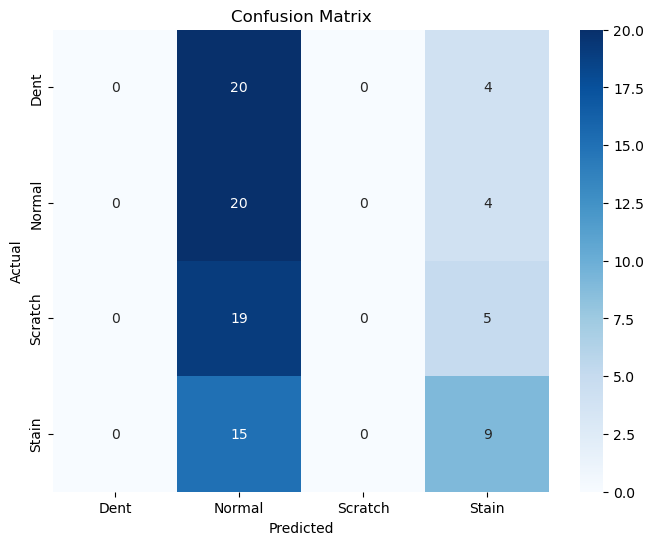

In [9]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# -----------------------------------------
# Predictions
# -----------------------------------------

Y_pred = model.predict(validation_generator)

y_pred = np.argmax(Y_pred, axis=1)

# True Labels
y_true = validation_generator.classes

# -----------------------------------------
# Confusion Matrix
# -----------------------------------------

cm = confusion_matrix(y_true, y_pred)

# -----------------------------------------
# Plot Confusion Matrix
# -----------------------------------------

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=validation_generator.class_indices.keys(),
    yticklabels=validation_generator.class_indices.keys()
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()

In [14]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image

# Folder path
dent_path = r"E:\BITSOM\Assignment 5\Part 2\dataset\Dent\dent"

# First image
first_image = os.listdir(dent_path)[0]

# Full path
img_path = os.path.join(dent_path, first_image)

print("Using image:", img_path)

# Load image
img = image.load_img(
    img_path,
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

class_labels = ['Dent', 'Normal', 'Scratch', 'Stain']

print("Predicted Class:", class_labels[predicted_class])

Using image: E:\BITSOM\Assignment 5\Part 2\dataset\Dent\dent\dent_001.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
Predicted Class: Normal


In [16]:
import os

os.makedirs("results", exist_ok=True)
os.makedirs("sample_predictions", exist_ok=True)

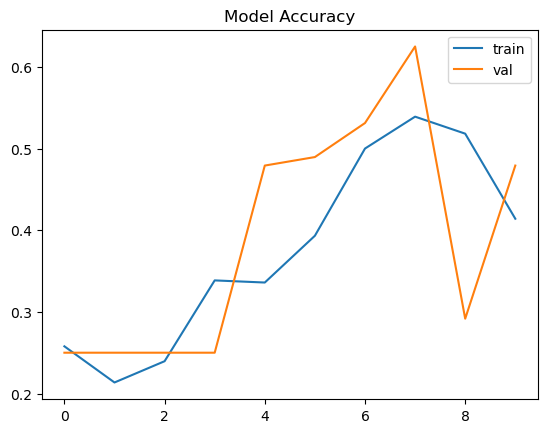

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['train','val'])
plt.savefig("results/accuracy_loss_curves.png")
plt.show()

In [18]:
plt.savefig("results/accuracy_loss_curves.png")

<Figure size 640x480 with 0 Axes>

# Task 6: CNN Concept Explanation

## 1. What is Convolution?

Convolution is the process where a small filter (also called a kernel) moves across an image to detect important features such as:

* edges,
* textures,
* shapes,
* scratches,
* dents,
* and patterns.

The filter scans different parts of the image and creates feature maps that help the CNN understand visual information.

Mathematically:

(I*K)(i,j)=\sum_m\sum_n I(i-m,j-n)K(m,n)

In simple terms:

* convolution helps the CNN “look” at small sections of an image,
* learn patterns,
* and identify meaningful visual features automatically.

Example:

* early layers detect edges,
* deeper layers detect complex defect patterns.

---

# 2. Why is Pooling Used?

Pooling is used to reduce the size of feature maps while keeping the most important information.

The most common pooling method is:

* Max Pooling

Max pooling selects the highest value from a small region.

Example:

```text id="d7m3x8"
Original Feature Map → Smaller Feature Map
```

Benefits of pooling:

* reduces computation,
* speeds up training,
* decreases memory usage,
* reduces overfitting,
* makes the model more robust.

Pooling allows CNNs to focus on important features instead of unnecessary details.

---

# 3. Why is ReLU Commonly Used in CNNs?

ReLU (Rectified Linear Unit) is the most widely used activation function in CNNs.

Formula:

f(x)=\max(0,x)

This means:

* negative values become 0,
* positive values remain unchanged.

Why ReLU is useful:

* introduces non-linearity,
* helps CNNs learn complex patterns,
* speeds up training,
* reduces the vanishing gradient problem.

Without ReLU, the CNN would behave like a simple linear model and would not learn complicated image features effectively.

---

# 4. Why are CNNs Better Than Regular Feed-Forward Networks for Image Data?

CNNs are specifically designed for image processing, while regular feed-forward neural networks are not efficient for images.

Advantages of CNNs:

| CNN Advantage           | Explanation                                           |
| ----------------------- | ----------------------------------------------------- |
| Local Feature Detection | CNNs detect edges, textures, and patterns locally     |
| Parameter Sharing       | Same filters are reused across the image              |
| Spatial Awareness       | CNNs preserve image structure                         |
| Lower Computation       | Fewer parameters compared to fully connected networks |
| Better Accuracy         | CNNs learn visual features more effectively           |

In regular feed-forward networks:

* images must be flattened into long vectors,
* spatial relationships between pixels are lost,
* computation becomes very expensive.

CNNs solve this problem using:

* convolution,
* pooling,
* and hierarchical feature learning.

Therefore, CNNs achieve:

* higher accuracy,
* faster training,
* and better image understanding.

---

# Conclusion

CNNs are highly effective for image classification because they automatically learn visual patterns using:

* convolution layers,
* ReLU activation,
* pooling layers,
* and dense layers.

These components allow CNNs to efficiently identify image features and outperform traditional feed-forward neural networks in computer vision tasks.


# Task 7: Business Use Case Mapping

## Real-World Domain: Manufacturing Industry

This type of computer vision solution can be widely used in the manufacturing industry for automated quality inspection and defect detection.

In manufacturing plants, products such as:

* metal sheets,
* automobile parts,
* electronic components,
* machinery surfaces,
* and packaged goods must be inspected for defects before being delivered to customers.

Traditionally, defect inspection is performed manually by human workers. Manual inspection can be:

* time-consuming,
* expensive,
* inconsistent,
* and prone to human error.

A CNN-based computer vision system can automatically detect defects such as:

* dents,
* scratches,
* stains,
* cracks,
* and surface irregularities from product images in real time.

---

# How the System Works

1. Cameras capture images of products on the production line.
2. The CNN model processes the images.
3. The system classifies products as:

   * Normal
   * Dent
   * Scratch
   * Stain
4. Defective products are automatically flagged or removed.

---

# Benefits to Manufacturing

| Benefit                | Explanation                                  |
| ---------------------- | -------------------------------------------- |
| Faster Inspection      | Automated systems inspect products instantly |
| Improved Accuracy      | Reduces human errors                         |
| Lower Costs            | Minimizes manual labor expenses              |
| Better Product Quality | Detects defects consistently                 |
| Real-Time Monitoring   | Continuous quality control during production |

---

# Example Use Cases

## Automobile Industry

Detect:

* dents,
* paint scratches,
* body defects
  on vehicle parts.

## Electronics Manufacturing

Identify:

* damaged screens,
* scratches,
* component defects.

## Steel and Metal Industry

Inspect metal surfaces for:

* cracks,
* stains,
* surface damage.

---

# Conclusion

CNN-based computer vision systems are highly valuable in manufacturing because they automate defect detection and quality inspection processes.

By using image classification models, companies can:

* improve efficiency,
* reduce operational costs,
* maintain high product quality,
* and enhance customer satisfaction.

This demonstrates how deep learning and computer vision can solve real-world industrial problems effectively.



In [1]:
import os

os.makedirs("sample_predictions", exist_ok=True)

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# -----------------------------------------
# CNN Model
# -----------------------------------------

model = Sequential([

    # Input Layer
    Input(shape=(128,128,3)),

    # First Convolution Layer
    Conv2D(32, (3,3), activation='relu'),

    # First Pooling Layer
    MaxPooling2D(pool_size=(2,2)),

    # Second Convolution Layer
    Conv2D(64, (3,3), activation='relu'),

    # Second Pooling Layer
    MaxPooling2D(pool_size=(2,2)),

    # Third Convolution Layer
    Conv2D(128, (3,3), activation='relu'),

    # Third Pooling Layer
    MaxPooling2D(pool_size=(2,2)),

    # Flatten Layer
    Flatten(),

    # Dense Layer
    Dense(128, activation='relu'),

    # Dropout Layer
    Dropout(0.5),

    # Output Layer
    Dense(4, activation='softmax')
])

# -----------------------------------------
# Compile Model
# -----------------------------------------

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model created successfully.")

Model created successfully.


In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# -----------------------------------------
# Dataset Path
# -----------------------------------------

dataset_path = r"E:\BITSOM\Assignment 5\Part 2\dataset"

# -----------------------------------------
# Image Parameters
# -----------------------------------------

IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

# -----------------------------------------
# Data Preprocessing
# -----------------------------------------

train_datagen = ImageDataGenerator(

    # Normalize pixel values
    rescale=1./255,

    # Data augmentation
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,

    # Split dataset
    validation_split=0.2
)

# -----------------------------------------
# Training Dataset
# -----------------------------------------

train_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(IMG_HEIGHT, IMG_WIDTH),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training'
)

# -----------------------------------------
# Validation Dataset
# -----------------------------------------

validation_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(IMG_HEIGHT, IMG_WIDTH),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation'
)

print("Dataset loaded successfully.")


Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.
Dataset loaded successfully.


In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.2839 - loss: 1.4245 - val_accuracy: 0.2500 - val_loss: 1.3869
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 641ms/step - accuracy: 0.2448 - loss: 1.3828 - val_accuracy: 0.2500 - val_loss: 1.3559
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 631ms/step - accuracy: 0.3646 - loss: 1.3595 - val_accuracy: 0.4375 - val_loss: 1.3559
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 622ms/step - accuracy: 0.3958 - loss: 1.2444 - val_accuracy: 0.5312 - val_loss: 1.1330
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 623ms/step - accuracy: 0.3359 - loss: 1.3270 - val_accuracy: 0.2500 - val_loss: 1.3686
Epoch 6/10
 7/12 ━━━━━━━━━━━━━━━━━━━━ 2s 533ms/step - accuracy: 0.3312 - loss: 1.3515